# NYC Urban Heat Island — OLS Regression Analysis

Block-level OLS regression of summer 2020 land surface temperature (LST) on physical/environmental predictors, with Moran's I diagnostic on residuals to acknowledge spatial autocorrelation.

**Inputs:**
- `NYC_block_combined_data.csv` — output from the data-build notebook

**Outputs (written to `./outputs/`):**
- `coefficients.csv` — OLS coefficient table
- `correlation_matrix.png` — predictor correlation heatmap
- `diagnostics.png` — fitted vs residuals + Q–Q plot
- `morans_i.txt` — Moran's I result on residuals

## 1. Imports and configuration

In [21]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from numpy import log

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
DATA_CSV = "NYC_block_combined_data.csv"
OUTDIR = Path("outputs")
OUTDIR.mkdir(exist_ok=True)

OUTCOME = "lst_mean"

# `min_dist_to_buildings` excluded because it is 0 for ~90% of blocks and
# carries no usable variation. `grass_pct` kept for completeness despite
# being very sparse in the NLCD-derived layer.
PREDICTORS = [
    "ndvi_mean",
    "tree_canopy_pct",
    "impervious_pct",
    "grass_pct",
    "building_density",
    "mean_building_height_m",
    "mean_dist_to_park",
    "mean_dist_to_water",
    "mean_dist_to_buildings",
]

## 2. Load and prepare data

Load the block-level table, drop any rows with missing modeling values, and confirm sample size.

In [3]:
df = pd.read_csv(DATA_CSV)
print(f"Loaded {len(df):,} blocks, {df.shape[1]} columns")

analysis_cols = [OUTCOME] + PREDICTORS
n_before = len(df)
df = df.dropna(subset=analysis_cols).copy()
print(f"Dropped {n_before - len(df):,} rows with missing modeling values")
print(f"Final analytical sample: {len(df):,} blocks")

Loaded 37,274 blocks, 38 columns
Dropped 0 rows with missing modeling values
Final analytical sample: 37,274 blocks


In [4]:
df

,GISJOIN,STATEFP20,COUNTYFP20,TRACTCE20,BLOCKCE20,GEOID20,NAME20,MTFCC20,UR20,UACE20,...,mean_dist_to_water,min_dist_to_water,mean_dist_to_buildings,min_dist_to_buildings,building_footprint_m2,mean_building_height_m,building_density,is_residential,centroid_x,centroid_y
0,G36000500001001000,36,5,100,1000,360050001001000,Block 1000,G5040,NaN,NaN,...,111.196028,0.000000,89.891124,0.0,46122.562582,5.649949,0.098380,1,594716.420176,4.515967e+06
1,G36000500001001001,36,5,100,1001,360050001001001,Block 1001,G5040,NaN,NaN,...,260.461967,30.000000,44.472472,0.0,98030.173116,11.459699,0.189354,1,594473.000885,4.516159e+06
2,G36000500001001002,36,5,100,1002,360050001001002,Block 1002,G5040,NaN,NaN,...,331.184999,120.000000,68.777481,30.0,0.000000,0.000000,0.000000,1,594125.043854,4.516201e+06
3,G36000500001001003,36,5,100,1003,360050001001003,Block 1003,G5040,NaN,NaN,...,187.770477,0.000000,41.800165,0.0,177767.553992,11.558308,0.262749,1,593795.173689,4.516317e+06
4,G36000500002001000,36,5,200,1000,360050002001000,Block 1000,G5040,NaN,NaN,...,401.007457,342.052612,25.363178,0.0,5003.380845,8.072731,0.261689,1,596159.039864,4.518753e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37269,G36008500323001021,36,85,32300,1021,360850323001021,Block 1021,G5040,NaN,NaN,...,91.698915,30.000000,50.719490,0.0,8604.881942,8.800436,0.226907,1,569951.170886,4.497614e+06
37270,G36008500323001022,36,85,32300,1022,360850323001022,Block 1022,G5040,NaN,NaN,...,77.492450,0.000000,101.098675,0.0,8622.901363,10.069362,0.028457,1,570157.775187,4.497454e+06
37271,G36008500323001023,36,85,32300,1023,360850323001023,Block 1023,G5040,NaN,NaN,...,72.363617,30.000000,80.924113,30.0,0.000000,0.000000,0.000000,0,569772.880834,4.497578e+06
37272,G36008500323001024,36,85,32300,1024,360850323001024,Block 1024,G5040,NaN,NaN,...,58.841438,0.000000,106.885246,30.0,0.000000,0.000000,0.000000,0,569612.869546,4.497546e+06


## 3. Descriptive summary

In [5]:
desc = df[analysis_cols].describe().T[["mean", "std", "min", "max"]].round(3)
desc.to_csv(OUTDIR / "variable_summary.csv")
desc

,mean,std,min,max
lst_mean,42.828,2.961,29.201,53.798
ndvi_mean,0.130,0.063,0.007,0.452
tree_canopy_pct,3.225,7.254,0.000,82.394
impervious_pct,79.913,15.135,0.000,100.000
grass_pct,0.026,0.755,0.000,58.907
building_density,0.259,0.151,0.000,1.000
mean_building_height_m,11.764,15.605,0.000,427.025
mean_dist_to_park,266.989,231.300,0.000,3006.220
mean_dist_to_water,938.970,717.174,0.000,3679.462
mean_dist_to_buildings,34.785,36.803,4.286,1871.694


## 4. Correlation matrix

Pairwise Pearson correlations among LST and predictors. Look for: (a) the *sign* of LST correlations against each predictor (vegetation should cool, impervious surfaces should warm), and (b) strongly correlated predictor pairs that may cause multicollinearity in the regression.

In [6]:
corr = df[analysis_cols].corr()
print("Correlations of each predictor with LST:")
print(corr["lst_mean"].drop("lst_mean").round(3).sort_values())

Correlations of each predictor with LST:
ndvi_mean                -0.337
tree_canopy_pct          -0.333
mean_dist_to_buildings   -0.235
mean_building_height_m   -0.118
grass_pct                -0.074
mean_dist_to_water        0.066
mean_dist_to_park         0.089
building_density          0.098
impervious_pct            0.346
Name: lst_mean, dtype: float64


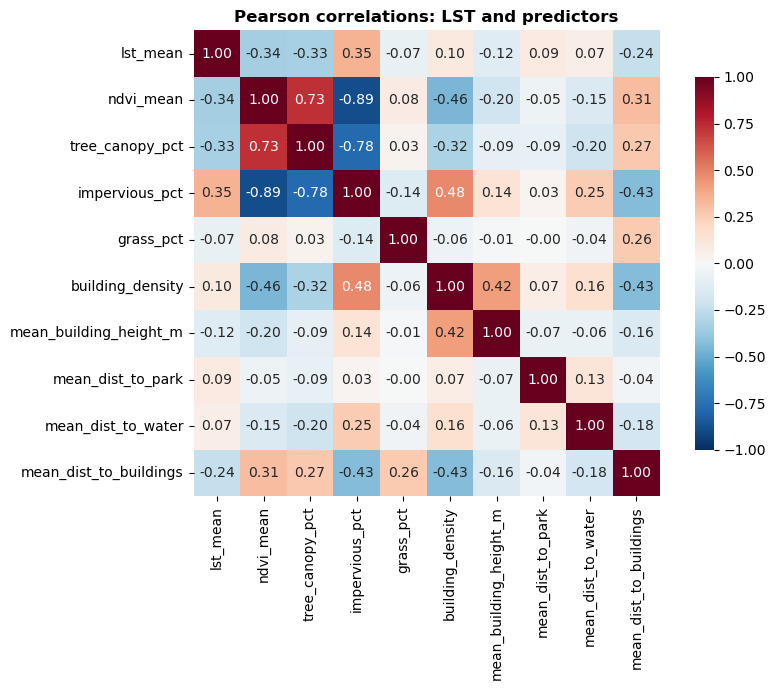

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title("Pearson correlations: LST and predictors", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTDIR / "correlation_matrix.png", dpi=150)
plt.show()

## 5. Multicollinearity check (VIF)

Variance Inflation Factors quantify how much a predictor's variance is inflated by correlation with the *other* predictors.

- VIF ≈ 1: no collinearity
- VIF > 5: concerning
- VIF > 10: serious problem

In [8]:
X_vif = sm.add_constant(df[PREDICTORS])
vif = (
    pd.DataFrame(
        {
            "predictor": X_vif.columns,
            "VIF": [
                variance_inflation_factor(X_vif.values, i)
                for i in range(X_vif.shape[1])
            ],
        }
    )
    .query("predictor != 'const'")
    .sort_values("VIF", ascending=False)
)
vif.to_csv(OUTDIR / "vif.csv", index=False)
vif

,predictor,VIF
3,impervious_pct,7.007373
1,ndvi_mean,5.347295
2,tree_canopy_pct,2.673832
5,building_density,1.718843
9,mean_dist_to_buildings,1.479054
6,mean_building_height_m,1.272806
8,mean_dist_to_water,1.135973
4,grass_pct,1.092581
7,mean_dist_to_park,1.047950


## 6. OLS regression on standardized predictors

In [9]:
X_std = (df[PREDICTORS] - df[PREDICTORS].mean()) / df[PREDICTORS].std()
X_std = sm.add_constant(X_std)
y = df[OUTCOME]

model = sm.OLS(y, X_std).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               lst_mean   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     972.2
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:00:38   Log-Likelihood:                -89426.
No. Observations:               37274   AIC:                         1.789e+05
Df Residuals:                   37264   BIC:                         1.790e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     42

In [10]:
# Tidy coefficient table
coef_table = pd.DataFrame(
    {
        "predictor": model.params.index,
        "std_coef": model.params.values,
        "std_err": model.bse.values,
        "t": model.tvalues.values,
        "p_value": model.pvalues.values,
        "ci_low": model.conf_int()[0].values,
        "ci_high": model.conf_int()[1].values,
    }
)
coef_table.to_csv(OUTDIR / "coefficients.csv", index=False)

print(f"R² = {model.rsquared:.3f}    Adj R² = {model.rsquared_adj:.3f}")
print(f"N  = {int(model.nobs):,}")
coef_table.round(4)

R² = 0.190    Adj R² = 0.190
N  = 37,274


,predictor,std_coef,std_err,t,p_value,ci_low,ci_high
0,const,42.8282,0.0138,3102.2020,0.0000,42.8012,42.8553
1,ndvi_mean,-0.6480,0.0319,-20.2974,0.0000,-0.7106,-0.5854
2,tree_canopy_pct,-0.4345,0.0226,-19.2451,0.0000,-0.4787,-0.3902
3,impervious_pct,0.0718,0.0365,1.9638,0.0496,0.0001,0.1434
4,grass_pct,-0.0273,0.0144,-1.8908,0.0587,-0.0556,0.0010
5,building_density,-0.1723,0.0181,-9.5167,0.0000,-0.2077,-0.1368
6,mean_building_height_m,-0.5346,0.0156,-34.3240,0.0000,-0.5651,-0.5041
7,mean_dist_to_park,0.1619,0.0141,11.4557,0.0000,0.1342,0.1896
8,mean_dist_to_water,-0.1319,0.0147,-8.9665,0.0000,-0.1608,-0.1031
9,mean_dist_to_buildings,-0.5175,0.0168,-30.8190,0.0000,-0.5504,-0.4846


## 7. Coefficient plot

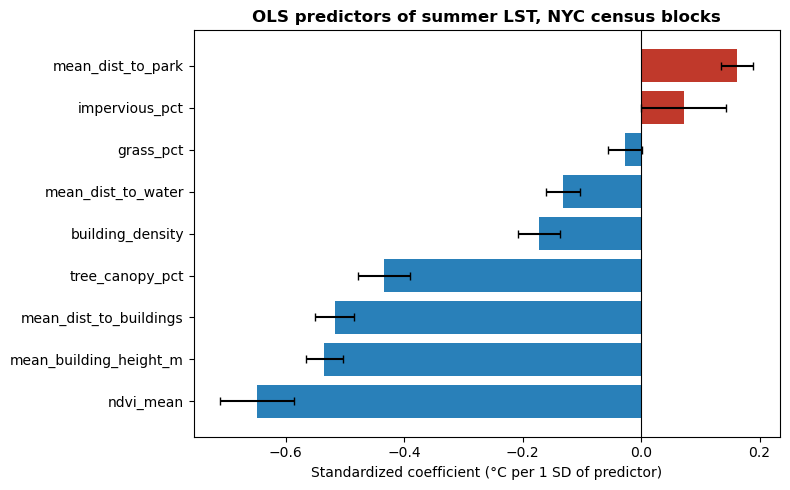

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = (
    coef_table.query("predictor != 'const'")
    .assign(abs_coef=lambda d: d.std_coef.abs())
    .sort_values("std_coef")
)
colors = ["#c0392b" if c > 0 else "#2980b9" for c in plot_df["std_coef"]]
ax.barh(
    plot_df["predictor"],
    plot_df["std_coef"],
    color=colors,
    xerr=1.96 * plot_df["std_err"],
    capsize=3,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardized coefficient (°C per 1 SD of predictor)")
ax.set_title("OLS predictors of summer LST, NYC census blocks", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTDIR / "coefficient_plot.png", dpi=150)
plt.show()

## 8. Residual diagnostics

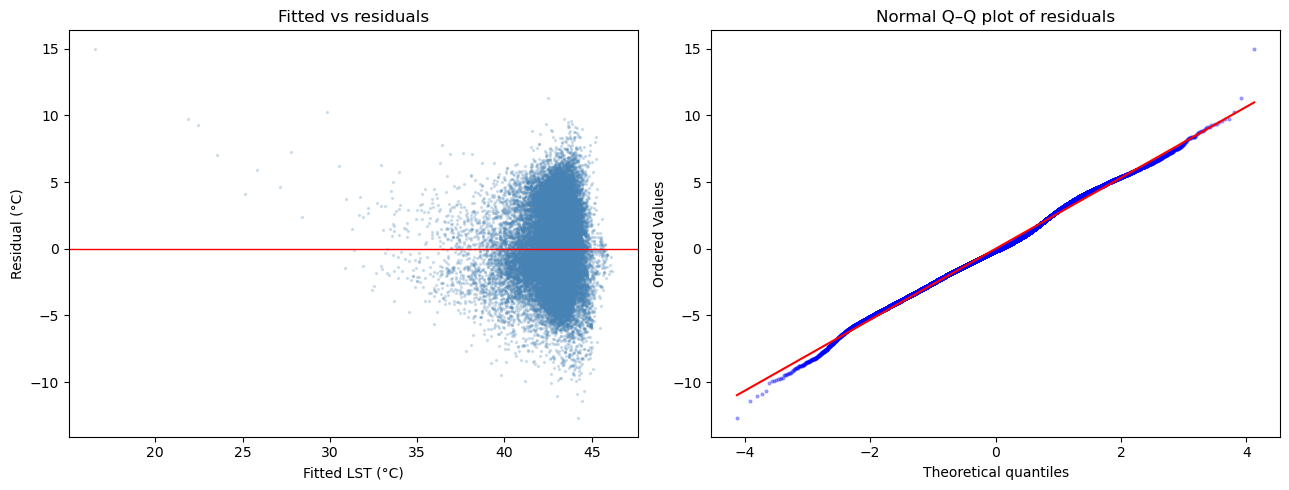

In [12]:
residuals = model.resid
fitted = model.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(fitted, residuals, s=2, alpha=0.2, color="steelblue")
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_xlabel("Fitted LST (°C)")
axes[0].set_ylabel("Residual (°C)")
axes[0].set_title("Fitted vs residuals")

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q–Q plot of residuals")
axes[1].get_lines()[0].set_markersize(2)
axes[1].get_lines()[0].set_alpha(0.3)

plt.tight_layout()
plt.savefig(OUTDIR / "diagnostics.png", dpi=150)
plt.show()

# Attach residuals back to the dataframe for spatial work below
df["resid"] = residuals

## 9. Spatial autocorrelation: Moran's I on residuals

Per Tobler's First Law, nearby blocks tend to have similar LST. If our model adequately captured the systematic spatial structure, residuals should be (near-)random in space. Moran's I tests this:

- **I ≈ 0**: random (good)
- **I > 0**: positive spatial autocorrelation — residuals cluster (model is missing spatial structure)
- **I < 0**: checkerboard pattern (very rare in environmental data)

**Spatial weights**: k-nearest-neighbors (k = 8) on block centroids. Fast, doesn't require contiguity computation, and robust to irregular block shapes.


In [13]:
from libpysal.weights import KNN
from esda.moran import Moran

coords = df[["centroid_x", "centroid_y"]].values
print(f"Building KNN(k=8) weights on {len(df):,} block centroids...")
w = KNN.from_array(coords, k=8)
w.transform = "r"  # row-standardize

print("Computing Moran's I (this takes ~30s)...")
moran = Moran(df["resid"].values, w, permutations=999)

print(f"\nMoran's I        = {moran.I:.4f}")
print(f"Expected I       = {moran.EI:.4f}")
print(f"z-score          = {moran.z_norm:.2f}")
print(f"p-value (perm)   = {moran.p_sim:.4f}")
print(f"Permutations     = 999")

ModuleNotFoundError: No module named 'libpysal'

**Interpretation**: Moran's I of 0.866 (z = 348.5, p = 0.001 with 999 permutations) shows very strong positive spatial autocorrelation in the OLS residuals. Blocks where the model over-predicts LST tend to sit next to other over-predicted blocks, and the same holds for under-predicted blocks. The theoretical maximum of Moran's I is 1, so a value of 0.866 is very high. This means that even after accounting for vegetation, impervious surface, building form, and distance to parks and water, a lot of spatial structure in temperature is still unexplained. This is what Tobler's First Law predicts: nearby blocks are more alike than distant ones, for reasons our predictors do not capture. Likely causes include microclimate, wind and sea-breeze patterns, neighborhood-scale built form, and unmeasured surface materials. Because of this autocorrelation, the OLS standard errors and p-values reported above are probably too small. The Durbin–Watson statistic of 0.27 supports this concern. Coefficients should therefore be interpreted with caution.

## 10. Exploring other Models

- Removing variables with high correlation (VIF > 5) and re-running OLS
- Testing out categorical variables (ex. building height or impervious surface)


## 11. Reviewing VIF & Running new OLS with variables < 5


In [14]:
vif

,predictor,VIF
3,impervious_pct,7.007373
1,ndvi_mean,5.347295
2,tree_canopy_pct,2.673832
5,building_density,1.718843
9,mean_dist_to_buildings,1.479054
6,mean_building_height_m,1.272806
8,mean_dist_to_water,1.135973
4,grass_pct,1.092581
7,mean_dist_to_park,1.047950


From the VIF scores, the % Impervious and the Mean NDVI variables were above 5. This means that they will be removed in the second round of regression analysis.

In [15]:
# revised predictors with mean NDVI and % impervious removed
PREDICTORS_VIF = [
    "tree_canopy_pct",
    "grass_pct",
    "building_density",
    "mean_building_height_m",
    "mean_dist_to_park",
    "mean_dist_to_water",
    "mean_dist_to_buildings",
]

Re-doing the OLS standardized regression with our VIF filtered predictor variables. 

In [16]:
X_std_VIF = (df[PREDICTORS_VIF] - df[PREDICTORS_VIF].mean()) / df[PREDICTORS_VIF].std()
X_std_VIF = sm.add_constant(X_std_VIF)
y_VIF = df[OUTCOME]

model_VIF = sm.OLS(y_VIF, X_std_VIF).fit()
print(model_VIF.summary())

                            OLS Regression Results                            
Dep. Variable:               lst_mean   R-squared:                       0.168
Model:                            OLS   Adj. R-squared:                  0.168
Method:                 Least Squares   F-statistic:                     1076.
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:05:11   Log-Likelihood:                -89927.
No. Observations:               37274   AIC:                         1.799e+05
Df Residuals:                   37266   BIC:                         1.799e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     42

In [17]:
# revised predictors with mean NDVI and % impervious removed
PREDICTORS_VIF2 = [
    "tree_canopy_pct",
    "grass_pct",
    "mean_building_height_m",
    "mean_dist_to_park",
    "mean_dist_to_water",
    "mean_dist_to_buildings",
]

X_std_VIF2 = (df[PREDICTORS_VIF2] - df[PREDICTORS_VIF2].mean()) / df[
    PREDICTORS_VIF2
].std()
X_std_VIF2 = sm.add_constant(X_std_VIF2)
y_VIF2 = df[OUTCOME]

model_VIF2 = sm.OLS(y_VIF2, X_std_VIF2).fit()
print(model_VIF2.summary())

                            OLS Regression Results                            
Dep. Variable:               lst_mean   R-squared:                       0.168
Model:                            OLS   Adj. R-squared:                  0.168
Method:                 Least Squares   F-statistic:                     1255.
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:09:05   Log-Likelihood:                -89927.
No. Observations:               37274   AIC:                         1.799e+05
Df Residuals:                   37267   BIC:                         1.799e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     42

Removing the high VIF variables decreased both the explanatory power (R2) and the AIC values of the models. Will look into the distributions of our variables. 

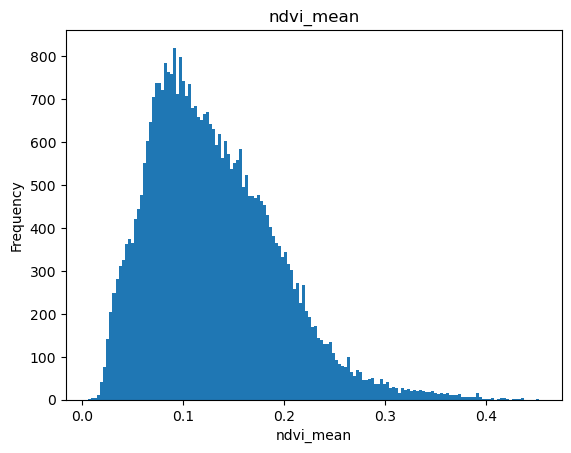

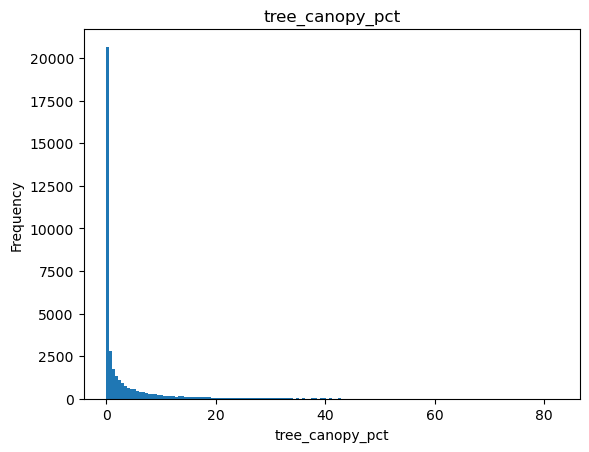

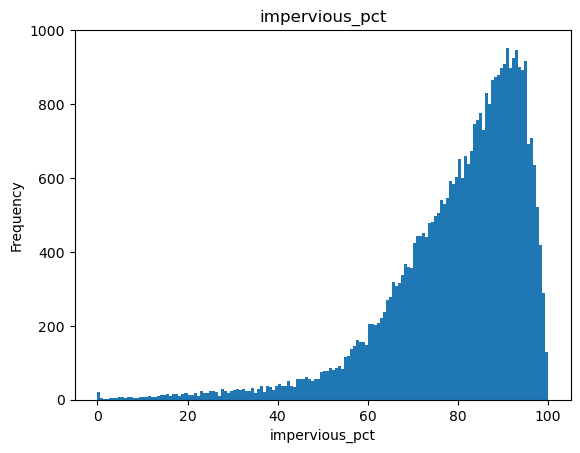

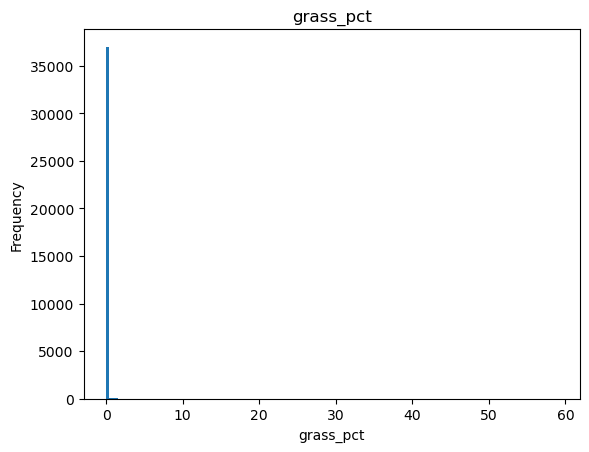

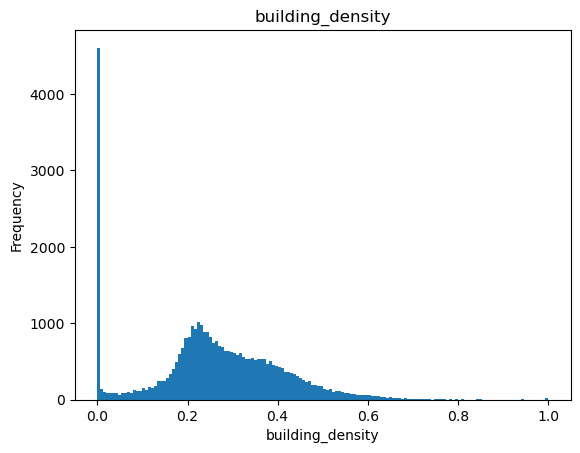

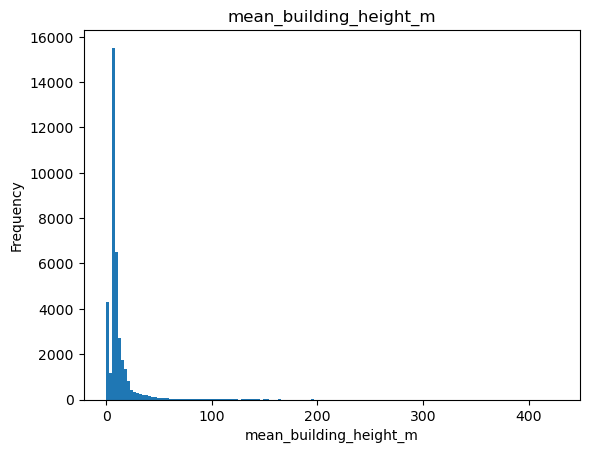

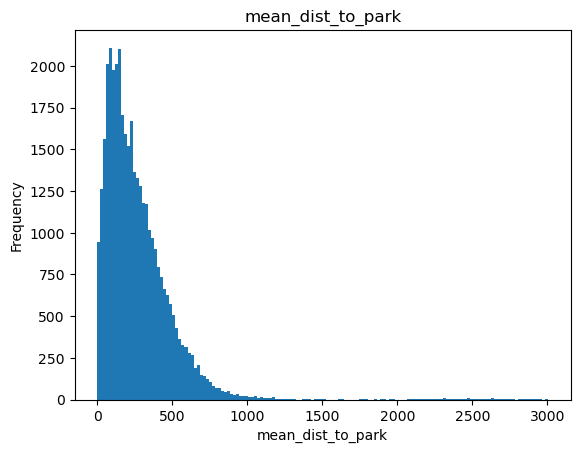

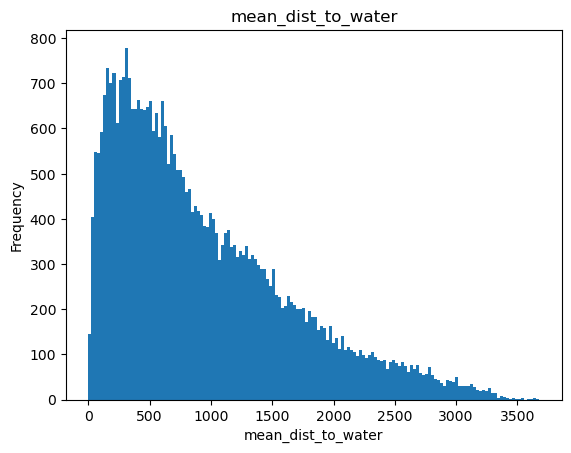

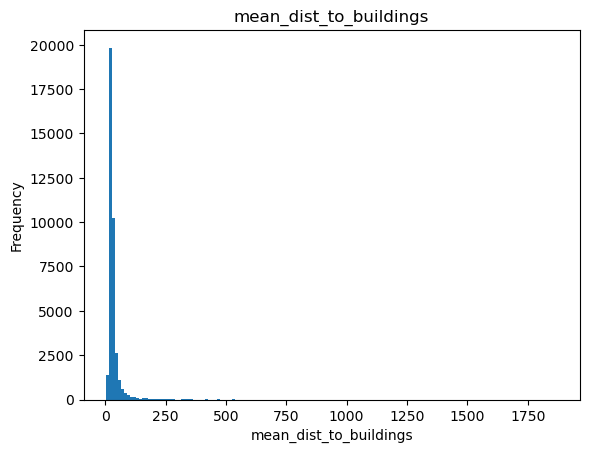

In [20]:
df_variables = df[PREDICTORS]

for col in df_variables.columns:
    plt.figure()
    df[col].plot(kind="hist", bins=150, title=col)
    plt.xlabel(col)
    plt.show()

In [ ]:
log_block_data = df_variables.copy()

for col in log_block_data.columns:
    log_block_data[col] = log(log_block_data[col])

c:\Users\gutgi\miniforge3\envs\geo_env\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


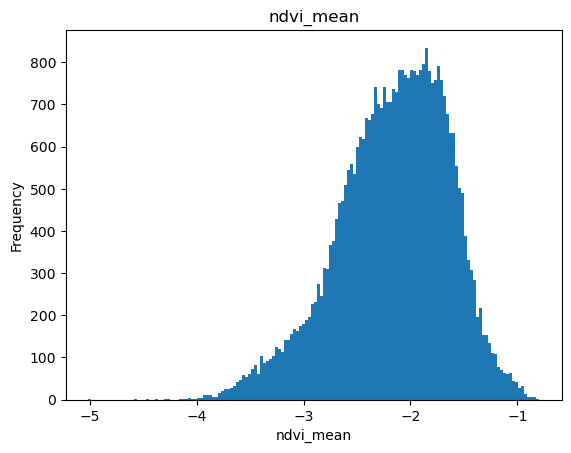

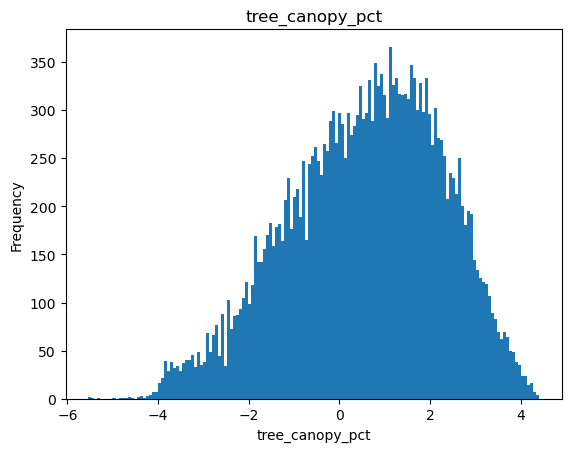

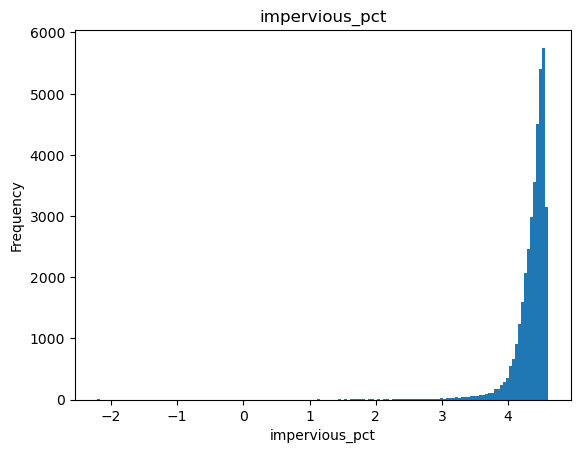

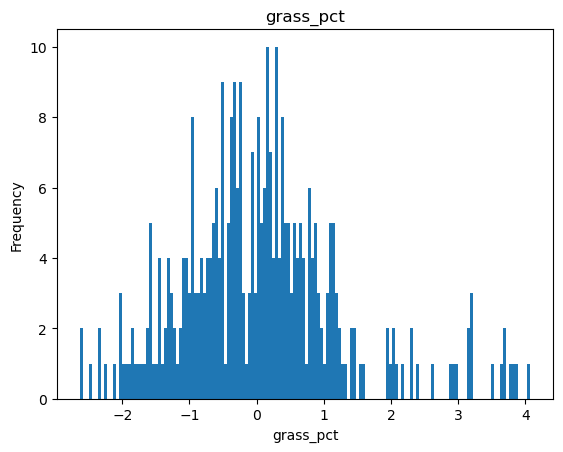

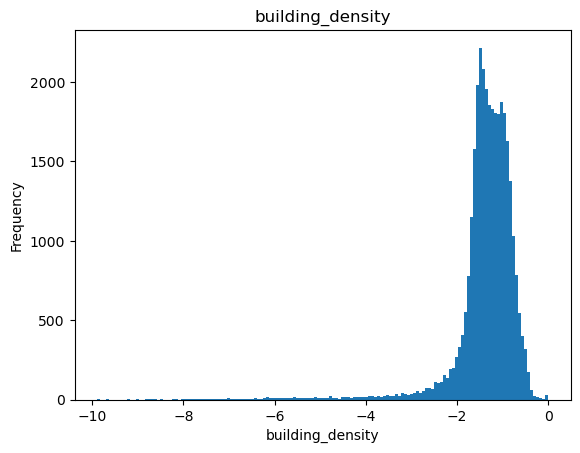

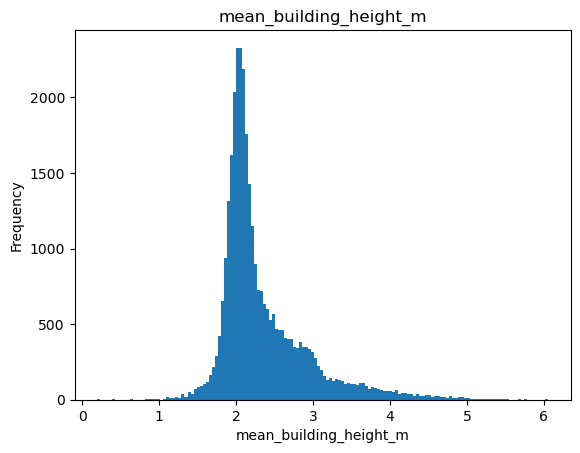

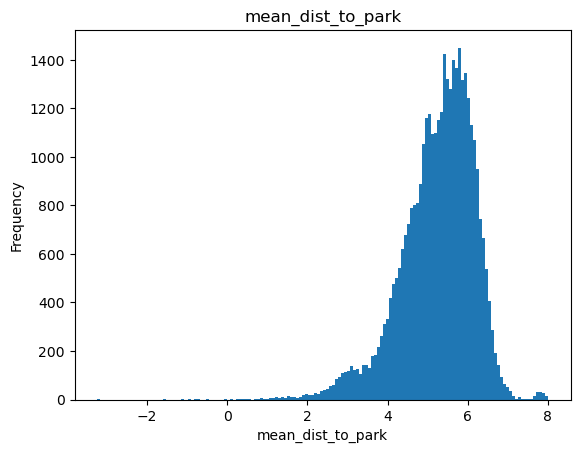

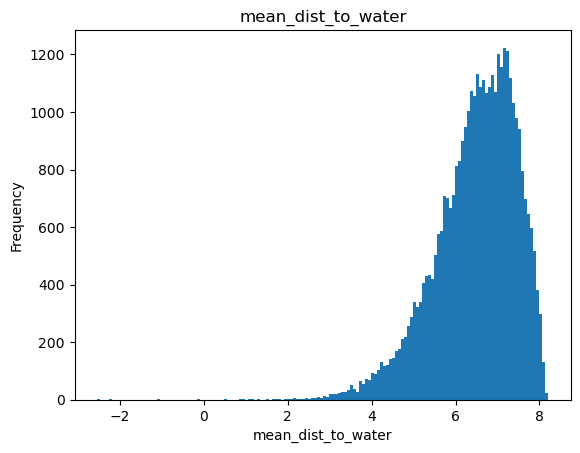

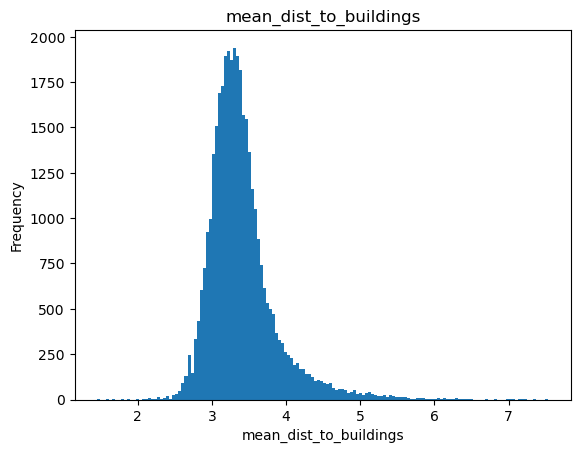

In [23]:
log_block_data.replace(-np.inf, np.nan, inplace=True)

for col in log_block_data.columns:
    plt.figure()
    log_block_data[col].plot(kind="hist", bins=150, title=col)
    plt.xlabel(col)
    plt.show()

In [25]:
OUTCOME = "lst_mean"

PREDICTORS = [
    "ndvi_mean",
    "tree_canopy_pct",
    "impervious_pct",
    "grass_pct",
    "building_density",
    "mean_building_height_m",
    "mean_dist_to_park",
    "mean_dist_to_water",
    "mean_dist_to_buildings",
]

# Subset the dataset
df_model = df[[OUTCOME] + PREDICTORS].copy()

# Check skewness BEFORE transforming
print("=== Skewness BEFORE log transform ===")
print(df_model[PREDICTORS].skew().round(2))

# Log transform ALL predictors
# log1p handles zeros safely
for var in PREDICTORS:
    df_model[f"log_{var}"] = np.log1p(df_model[var])
    df_model.drop(columns=var, inplace=True)

PREDICTORS_TRANSFORMED = [f"log_{var}" for var in PREDICTORS]

# Check skewness AFTER transforming
print("\n=== Skewness AFTER log transform ===")
print(df_model[PREDICTORS_TRANSFORMED].skew().round(2))

print(f"\nDataset shape: {df_model.shape}")

=== Skewness BEFORE log transform ===
ndvi_mean                  0.84
tree_canopy_pct            4.17
impervious_pct            -1.55
grass_pct                 51.31
building_density           0.10
mean_building_height_m     6.59
mean_dist_to_park          3.82
mean_dist_to_water         1.00
mean_dist_to_buildings    15.82
dtype: float64

=== Skewness AFTER log transform ===
log_ndvi_mean                  0.68
log_tree_canopy_pct            1.22
log_impervious_pct            -5.22
log_grass_pct                 21.13
log_building_density          -0.24
log_mean_building_height_m    -0.82
log_mean_dist_to_park         -0.95
log_mean_dist_to_water        -0.86
log_mean_dist_to_buildings     1.91
dtype: float64

Dataset shape: (37274, 10)


In [24]:
X_std_log = (
    log_block_data[PREDICTORS] - log_block_data[PREDICTORS].mean()
) / log_block_data[PREDICTORS].std()
X_std_log = sm.add_constant(X_std_log)
y_log = log_block_data[OUTCOME]

model_VIF2 = sm.OLS(y_log, X_std_log).fit()
print(model_VIF2.summary())

KeyError: 'lst_mean'

## 15. Summary

Outputs saved to `./outputs/`:
- `variable_summary.csv` — descriptive statistics
- `vif.csv` — multicollinearity diagnostics
- `coefficients.csv` — OLS coefficient table with CIs and p-values
- `correlation_matrix.png`
- `coefficient_plot.png`
- `diagnostics.png`
- `morans_i.txt` — spatial autocorrelation result